# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

In [1]:
# ============================================================
# COLAB PROJECT SETUP
# ============================================================

from google.colab import drive
from pathlib import Path
import os

# Mount Google Drive
drive.mount("/content/drive")

# Permanent project folder in Google Drive
DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Hybrid_RAG_Customer_Support"
)

# Temporary workspace for the current Colab runtime
LOCAL_PROJECT_DIR = Path(
    "/content/Hybrid_RAG_Customer_Support"
)

LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Work from the temporary Colab directory
os.chdir(LOCAL_PROJECT_DIR)

print("Google Drive project:", DRIVE_PROJECT_DIR)
print("Local Colab workspace:", LOCAL_PROJECT_DIR)
print("Current working directory:", Path.cwd())

Mounted at /content/drive
Google Drive project: /content/drive/MyDrive/Hybrid_RAG_Customer_Support
Local Colab workspace: /content/Hybrid_RAG_Customer_Support
Current working directory: /content/Hybrid_RAG_Customer_Support


## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [2]:
# YOUR CODE HERE
!pip install -q datasets

In [3]:
from pathlib import Path
import pandas as pd
from IPython.display import display

POLICY_DIR = Path(
    "/content/drive/MyDrive/Hybrid_RAG_Customer_Support/data/corporate_policies"
)

# Validate the directory
if not POLICY_DIR.exists():
    raise FileNotFoundError(
        f"Corporate policies folder not found: {POLICY_DIR}"
    )

# Locate all Markdown SOP files
policy_files = sorted(POLICY_DIR.glob("*.md"))

if not policy_files:
    raise FileNotFoundError(
        f"No Markdown files were found in: {POLICY_DIR}"
    )

# Create a summary of the available SOP documents
policy_summary = pd.DataFrame({
    "file_name": [file.name for file in policy_files],
    "size_bytes": [file.stat().st_size for file in policy_files],
    "is_non_empty": [file.stat().st_size > 0 for file in policy_files]
})

print(f"Policy directory: {POLICY_DIR}")
print(f"Number of SOP documents found: {len(policy_files)}\n")

display(policy_summary)

print(
    "All SOP documents are non-empty:",
    policy_summary["is_non_empty"].all()
)

Policy directory: /content/drive/MyDrive/Hybrid_RAG_Customer_Support/data/corporate_policies
Number of SOP documents found: 13



,file_name,size_bytes,is_non_empty
0,account_recovery.md,1555,True
1,billing_disputes.md,1667,True
2,data_privacy.md,1721,True
3,escalation_matrix.md,1566,True
4,order_tracking.md,1534,True
5,password_reset.md,1604,True
6,payment_methods.md,1631,True
7,product_return.md,1570,True
8,refund_policy.md,1746,True
9,shipping_delays.md,1548,True


All SOP documents are non-empty: True


In [4]:
from datasets import load_dataset

DATASET_ID = (
    "bitext/"
    "Bitext-customer-support-llm-chatbot-training-dataset"
)

# Download the dataset from Hugging Face
dataset = load_dataset(DATASET_ID)

print("Dataset structure:")
print(dataset)

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})


In [5]:
# The dataset currently provides a training split
split_name = "train" if "train" in dataset else next(iter(dataset))

bitext_dataset = dataset[split_name]
bitext_df = bitext_dataset.to_pandas()

print(f"Selected split: {split_name}")
print(f"Dataset shape: {bitext_df.shape}")
print("\nDataset features:")
print(bitext_dataset.features)

print("\nPandas dataset information:")
bitext_df.info()

print("\nFirst five records:")
display(bitext_df.head())

Selected split: train
Dataset shape: (26872, 5)

Dataset features:
{'flags': Value('string'), 'instruction': Value('string'), 'category': Value('string'), 'intent': Value('string'), 'response': Value('string')}

Pandas dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB

First five records:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
required_columns = ["instruction", "intent", "category"]

missing_columns = [
    column
    for column in required_columns
    if column not in bitext_df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

print("Required columns successfully identified:")
print(required_columns)

print("\nNull values in required columns:")
display(bitext_df[required_columns].isna().sum().to_frame("null_count"))

print("\nEmpty-string values in required columns:")
empty_counts = (
    bitext_df[required_columns]
    .fillna("")
    .apply(lambda column: column.astype(str).str.strip().eq("").sum())
    .to_frame("empty_string_count")
)

display(empty_counts)

print("\nUnique values:")
print("Categories:", bitext_df["category"].nunique())
print("Intents:", bitext_df["intent"].nunique())

Required columns successfully identified:
['instruction', 'intent', 'category']

Null values in required columns:


,null_count
instruction,0
intent,0
category,0



Empty-string values in required columns:


,empty_string_count
instruction,0
intent,0
category,0



Unique values:
Categories: 11
Intents: 27


#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [7]:
# YOUR CODE HERE
SAMPLE_SIZE = 4000
RANDOM_STATE = 42

# Original dataset characteristics
original_size = len(bitext_df)
unique_intents = bitext_df["intent"].nunique()
unique_categories = bitext_df["category"].nunique()
average_records_per_intent = original_size / unique_intents

print("Original dataset characteristics")
print("-" * 40)
print(f"Total records              : {original_size:,}")
print(f"Unique intents             : {unique_intents}")
print(f"Unique categories          : {unique_categories}")
print(f"Average records per intent : {average_records_per_intent:.2f}")

# Validate that the requested sample size is possible
if original_size < SAMPLE_SIZE:
    raise ValueError(
        f"The dataset contains only {original_size:,} records, "
        f"which is fewer than the requested sample size of {SAMPLE_SIZE:,}."
    )

# Create a reproducible 4,000-row sample
sampled_df = (
    bitext_df
    .sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("\nSampled dataset characteristics")
print("-" * 40)
print(f"Sampled records            : {len(sampled_df):,}")
print(f"Unique intents retained    : {sampled_df['intent'].nunique()}")
print(f"Unique categories retained : {sampled_df['category'].nunique()}")

display(sampled_df.head())

Original dataset characteristics
----------------------------------------
Total records              : 26,872
Unique intents             : 27
Unique categories          : 11
Average records per intent : 995.26

Sampled dataset characteristics
----------------------------------------
Sampled records            : 4,000
Unique intents retained    : 27
Unique categories retained : 11


,flags,instruction,category,intent,response
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...


#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [8]:
# YOUR CODE HERE
from pathlib import Path
import pandas as pd

REQUIRED_COLUMNS = ["instruction", "intent", "category"]
FINAL_SAMPLE_SIZE = 4000
RANDOM_STATE = 42


def clean_dataset(df):
    """Remove invalid records and normalised duplicate instructions."""

    cleaned = df.copy()

    # Remove records containing null values in required columns
    cleaned = cleaned.dropna(subset=REQUIRED_COLUMNS).copy()

    # Strip surrounding whitespace
    for column in REQUIRED_COLUMNS:
        cleaned[column] = cleaned[column].astype(str).str.strip()

    # Remove empty-string records
    non_empty_mask = (
        cleaned[REQUIRED_COLUMNS]
        .ne("")
        .all(axis=1)
    )
    cleaned = cleaned[non_empty_mask].copy()

    # Normalise customer instructions for duplicate detection
    cleaned["normalised_instruction"] = (
        cleaned["instruction"]
        .str.lower()
        .str.strip()
    )

    # Remove duplicate and near-duplicate instructions
    cleaned = cleaned.drop_duplicates(
        subset="normalised_instruction",
        keep="first"
    ).reset_index(drop=True)

    return cleaned

In [9]:
# Inspect quality of the original 4,000-row sample
print("Quality checks before cleaning")
print("-" * 45)

null_counts = sampled_df[REQUIRED_COLUMNS].isnull().sum()
empty_counts = (
    sampled_df[REQUIRED_COLUMNS]
    .fillna("")
    .apply(lambda col: col.astype(str).str.strip().eq("").sum())
)

normalised_instructions = (
    sampled_df["instruction"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

normalised_duplicate_count = (
    normalised_instructions.duplicated(keep="first").sum()
)

print(f"Initial sample size                : {len(sampled_df):,}")
print(f"Records with required-field nulls : "
      f"{sampled_df[REQUIRED_COLUMNS].isnull().any(axis=1).sum():,}")
print(f"Records with empty required fields: "
      f"{sampled_df[REQUIRED_COLUMNS].fillna('').apply(
          lambda col: col.astype(str).str.strip().eq('')
      ).any(axis=1).sum():,}")
print(f"Normalised duplicate instructions : "
      f"{normalised_duplicate_count:,}")

print("\nNull values by column:")
display(null_counts.to_frame("null_count"))

print("\nEmpty values by column:")
display(empty_counts.to_frame("empty_count"))

Quality checks before cleaning
---------------------------------------------
Initial sample size                : 4,000
Records with required-field nulls : 0
Records with empty required fields: 0
Normalised duplicate instructions : 98

Null values by column:


,null_count
instruction,0
intent,0
category,0



Empty values by column:


,empty_count
instruction,0
intent,0
category,0


In [10]:
# Clean the sampled dataset
cleaned_sample_df = clean_dataset(sampled_df)

removed_count = len(sampled_df) - len(cleaned_sample_df)

print("\nCleaning results")
print("-" * 45)
print(f"Rows before cleaning : {len(sampled_df):,}")
print(f"Rows removed         : {removed_count:,}")
print(f"Rows after cleaning  : {len(cleaned_sample_df):,}")


Cleaning results
---------------------------------------------
Rows before cleaning : 4,000
Rows removed         : 98
Rows after cleaning  : 3,902


In [11]:
# Replenish removed rows to retain exactly 4,000 records
if len(cleaned_sample_df) < FINAL_SAMPLE_SIZE:

    # Clean the complete dataset to create a valid replacement pool
    clean_full_df = clean_dataset(bitext_df)

    existing_instructions = set(
        cleaned_sample_df["normalised_instruction"]
    )

    replacement_pool = clean_full_df[
        ~clean_full_df["normalised_instruction"].isin(
            existing_instructions
        )
    ].copy()

    rows_required = FINAL_SAMPLE_SIZE - len(cleaned_sample_df)

    if len(replacement_pool) < rows_required:
        raise ValueError(
            f"Only {len(replacement_pool):,} replacement records are "
            f"available, but {rows_required:,} are required."
        )

    replacement_rows = replacement_pool.sample(
        n=rows_required,
        random_state=RANDOM_STATE
    )

    final_sample_df = pd.concat(
        [cleaned_sample_df, replacement_rows],
        ignore_index=True
    )

else:
    final_sample_df = cleaned_sample_df.iloc[
        :FINAL_SAMPLE_SIZE
    ].copy()


# Reproducibly shuffle the final dataset
final_sample_df = (
    final_sample_df
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Remove helper column before saving
final_sample_df = final_sample_df.drop(
    columns="normalised_instruction"
)

In [12]:
# Final validation
final_normalised_instructions = (
    final_sample_df["instruction"]
    .str.lower()
    .str.strip()
)

assert len(final_sample_df) == FINAL_SAMPLE_SIZE
assert not final_sample_df[REQUIRED_COLUMNS].isnull().any().any()
assert not (
    final_sample_df[REQUIRED_COLUMNS]
    .apply(lambda col: col.astype(str).str.strip().eq(""))
    .any()
    .any()
)
assert not final_normalised_instructions.duplicated().any()

print("\nFinal validation")
print("-" * 45)
print(f"Final records                  : {len(final_sample_df):,}")
print(f"Remaining null values          : "
      f"{final_sample_df[REQUIRED_COLUMNS].isnull().sum().sum()}")
print(f"Remaining empty required fields: 0")
print(f"Remaining normalised duplicates: "
      f"{final_normalised_instructions.duplicated().sum()}")
print(f"Unique intents                 : "
      f"{final_sample_df['intent'].nunique()}")
print(f"Unique categories              : "
      f"{final_sample_df['category'].nunique()}")


Final validation
---------------------------------------------
Final records                  : 4,000
Remaining null values          : 0
Remaining empty required fields: 0
Remaining normalised duplicates: 0
Unique intents                 : 27
Unique categories              : 11


In [13]:
# Verify that every intent maps consistently to one category
intent_category_mapping = (
    final_sample_df
    .groupby("intent")["category"]
    .nunique()
    .sort_values(ascending=False)
)

inconsistent_mappings = intent_category_mapping[
    intent_category_mapping > 1
]

print(
    "Intents mapped to multiple categories:",
    len(inconsistent_mappings)
)

if inconsistent_mappings.empty:
    print("All intents map consistently to one category.")
else:
    display(inconsistent_mappings)

Intents mapped to multiple categories: 0
All intents map consistently to one category.


### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

In [14]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

TOP_N = 10

# Calculate intent frequencies
intent_counts = final_sample_df["intent"].value_counts()
top_intents = intent_counts.head(TOP_N)

# Create a summary table
top_intent_summary = pd.DataFrame({
    "intent": top_intents.index,
    "record_count": top_intents.values,
    "percentage": (
        top_intents.values / len(final_sample_df) * 100
    ).round(2)
})

print(f"Total unique intents: {final_sample_df['intent'].nunique()}")
print("\nTop 10 most frequent intents:")
display(top_intent_summary)

Total unique intents: 27

Top 10 most frequent intents:


,intent,record_count,percentage
0,review,171,4.28
1,get_invoice,171,4.28
2,create_account,165,4.12
3,check_payment_methods,164,4.10
4,set_up_shipping_address,162,4.05
5,contact_customer_service,161,4.03
6,payment_issue,161,4.03
7,change_shipping_address,159,3.98
8,contact_human_agent,159,3.98
9,check_refund_policy,155,3.88


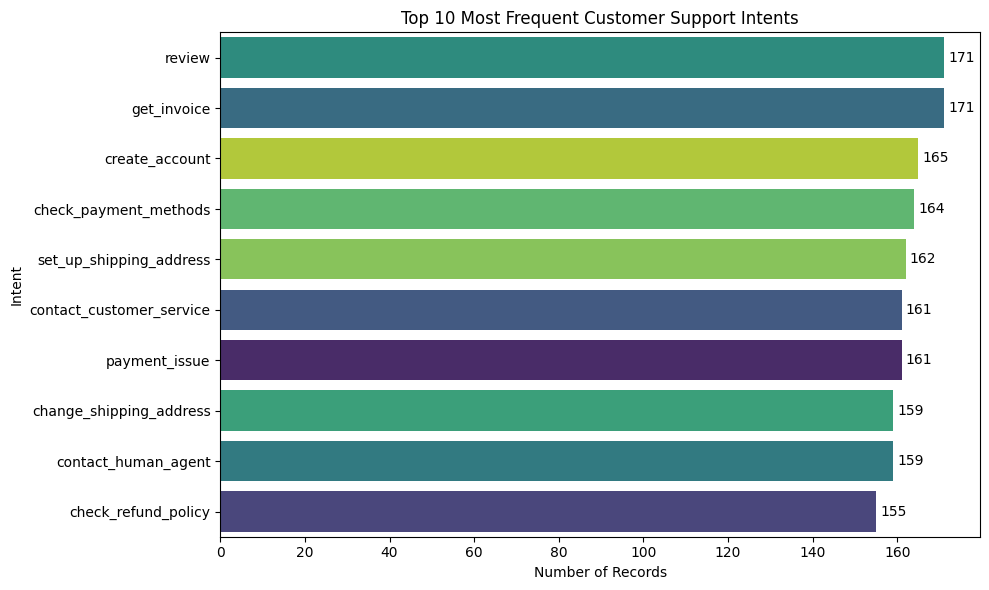

In [15]:
# Plot the top 10 intents
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=final_sample_df[
        final_sample_df["intent"].isin(top_intents.index)
    ],
    y="intent",
    order=top_intents.index,
    hue="intent",
    palette="viridis",
    legend=False
)

# Display record counts on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 10 Most Frequent Customer Support Intents")
plt.xlabel("Number of Records")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

In [16]:
# Check whether one intent severely dominates the dataset
dominant_intent = intent_counts.index[0]
dominant_count = intent_counts.iloc[0]
dominant_percentage = (
    dominant_count / len(final_sample_df) * 100
)

print("Class-balance assessment")
print("-" * 40)
print(f"Most frequent intent : {dominant_intent}")
print(f"Number of records    : {dominant_count}")
print(f"Dataset share        : {dominant_percentage:.2f}%")

if dominant_percentage > 80:
    print(
        "\nSevere class imbalance detected: one intent represents "
        "more than 80% of the dataset."
    )
else:
    print(
        "\nNo single intent represents more than 80% of the dataset."
    )

Class-balance assessment
----------------------------------------
Most frequent intent : review
Number of records    : 171
Dataset share        : 4.28%

No single intent represents more than 80% of the dataset.


### Interpretation

The cleaned sample contains 27 unique intents. The most frequent intents are
`review` and `get_invoice`, with 171 records each, representing 4.28% of the
dataset. The selected billing-related intents, `payment_issue` and
`check_payment_methods`, are also represented among the ten most frequent
classes.

No single intent exceeds the 80% dominance threshold. Therefore, the sampled
dataset does not exhibit severe class imbalance, although stratified sampling
should still be used when creating the training, validation, and test splits.

#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [17]:
# YOUR CODE HERE
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# Read the SOP Markdown documents
if not policy_files:
    raise ValueError(
        "No policy files are available. Run Task 1.2.1 first."
    )

policy_names = []
policy_texts = []

for file_path in policy_files:
    with open(file_path, "r", encoding="utf-8") as file:
        text = file.read().strip()

    if not text:
        raise ValueError(
            f"The policy document is empty: {file_path.name}"
        )

    policy_names.append(file_path.stem)
    policy_texts.append(text)

print(f"Policy documents loaded: {len(policy_texts)}")

Policy documents loaded: 13


In [18]:
# Convert the documents into TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    policy_texts
)

print("\nTF-IDF matrix information")
print("-" * 40)
print(f"Number of documents : {tfidf_matrix.shape[0]}")
print(f"Unique terms        : {tfidf_matrix.shape[1]}")
print(f"Matrix shape        : {tfidf_matrix.shape}")


TF-IDF matrix information
----------------------------------------
Number of documents : 13
Unique terms        : 797
Matrix shape        : (13, 797)


In [19]:
# Calculate pairwise cosine similarity
cosine_similarity_matrix = cosine_similarity(
    tfidf_matrix
)

similarity_df = pd.DataFrame(
    cosine_similarity_matrix,
    index=policy_names,
    columns=policy_names
)

print("\nCosine-similarity matrix:")
display(similarity_df.round(3))


Cosine-similarity matrix:


,account_recovery,billing_disputes,data_privacy,escalation_matrix,order_tracking,password_reset,payment_methods,product_return,refund_policy,shipping_delays,subscription_cancellation,technical_troubleshooting,working_hours
account_recovery,1.000,0.090,0.174,0.107,0.115,0.424,0.145,0.037,0.057,0.063,0.079,0.107,0.081
billing_disputes,0.090,1.000,0.085,0.166,0.094,0.045,0.264,0.162,0.278,0.135,0.141,0.114,0.039
data_privacy,0.174,0.085,1.000,0.203,0.049,0.107,0.060,0.031,0.057,0.033,0.106,0.166,0.027
escalation_matrix,0.107,0.166,0.203,1.000,0.059,0.050,0.099,0.051,0.106,0.097,0.062,0.192,0.089
order_tracking,0.115,0.094,0.049,0.059,1.000,0.136,0.074,0.129,0.112,0.379,0.046,0.080,0.118
password_reset,0.424,0.045,0.107,0.050,0.136,1.000,0.084,0.033,0.044,0.054,0.052,0.095,0.126
payment_methods,0.145,0.264,0.060,0.099,0.074,0.084,1.000,0.065,0.201,0.076,0.101,0.102,0.066
product_return,0.037,0.162,0.031,0.051,0.129,0.033,0.065,1.000,0.269,0.134,0.055,0.050,0.042
refund_policy,0.057,0.278,0.057,0.106,0.112,0.044,0.201,0.269,1.000,0.201,0.161,0.047,0.064
shipping_delays,0.063,0.135,0.033,0.097,0.379,0.054,0.076,0.134,0.201,1.000,0.053,0.055,0.147


In [20]:
# Identify the most similar SOP document pairs
similarity_pairs = []

for row_index in range(len(policy_names)):
    for column_index in range(row_index + 1, len(policy_names)):
        similarity_pairs.append({
            "policy_1": policy_names[row_index],
            "policy_2": policy_names[column_index],
            "cosine_similarity": cosine_similarity_matrix[
                row_index,
                column_index
            ]
        })

similarity_pairs_df = (
    pd.DataFrame(similarity_pairs)
    .sort_values(
        by="cosine_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTen most similar SOP document pairs:")
display(
    similarity_pairs_df
    .head(10)
    .round({"cosine_similarity": 3})
)


Ten most similar SOP document pairs:


,policy_1,policy_2,cosine_similarity
0,account_recovery,password_reset,0.424
1,order_tracking,shipping_delays,0.379
2,billing_disputes,refund_policy,0.278
3,product_return,refund_policy,0.269
4,billing_disputes,payment_methods,0.264
5,data_privacy,escalation_matrix,0.203
6,refund_policy,shipping_delays,0.201
7,payment_methods,refund_policy,0.201
8,escalation_matrix,technical_troubleshooting,0.192
9,account_recovery,data_privacy,0.174


In [21]:
# Check for potentially high policy overlap
HIGH_SIMILARITY_THRESHOLD = 0.70

high_similarity_pairs = similarity_pairs_df[
    similarity_pairs_df["cosine_similarity"]
    >= HIGH_SIMILARITY_THRESHOLD
]

print("Policy-overlap assessment")
print("-" * 40)

if high_similarity_pairs.empty:
    print(
        "No policy pairs have cosine similarity greater than "
        f"or equal to {HIGH_SIMILARITY_THRESHOLD:.2f}."
    )
else:
    print(
        f"{len(high_similarity_pairs)} policy pair(s) have "
        f"cosine similarity greater than or equal to "
        f"{HIGH_SIMILARITY_THRESHOLD:.2f}:"
    )

    display(
        high_similarity_pairs.round({
            "cosine_similarity": 3
        })
    )

Policy-overlap assessment
----------------------------------------
No policy pairs have cosine similarity greater than or equal to 0.70.


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

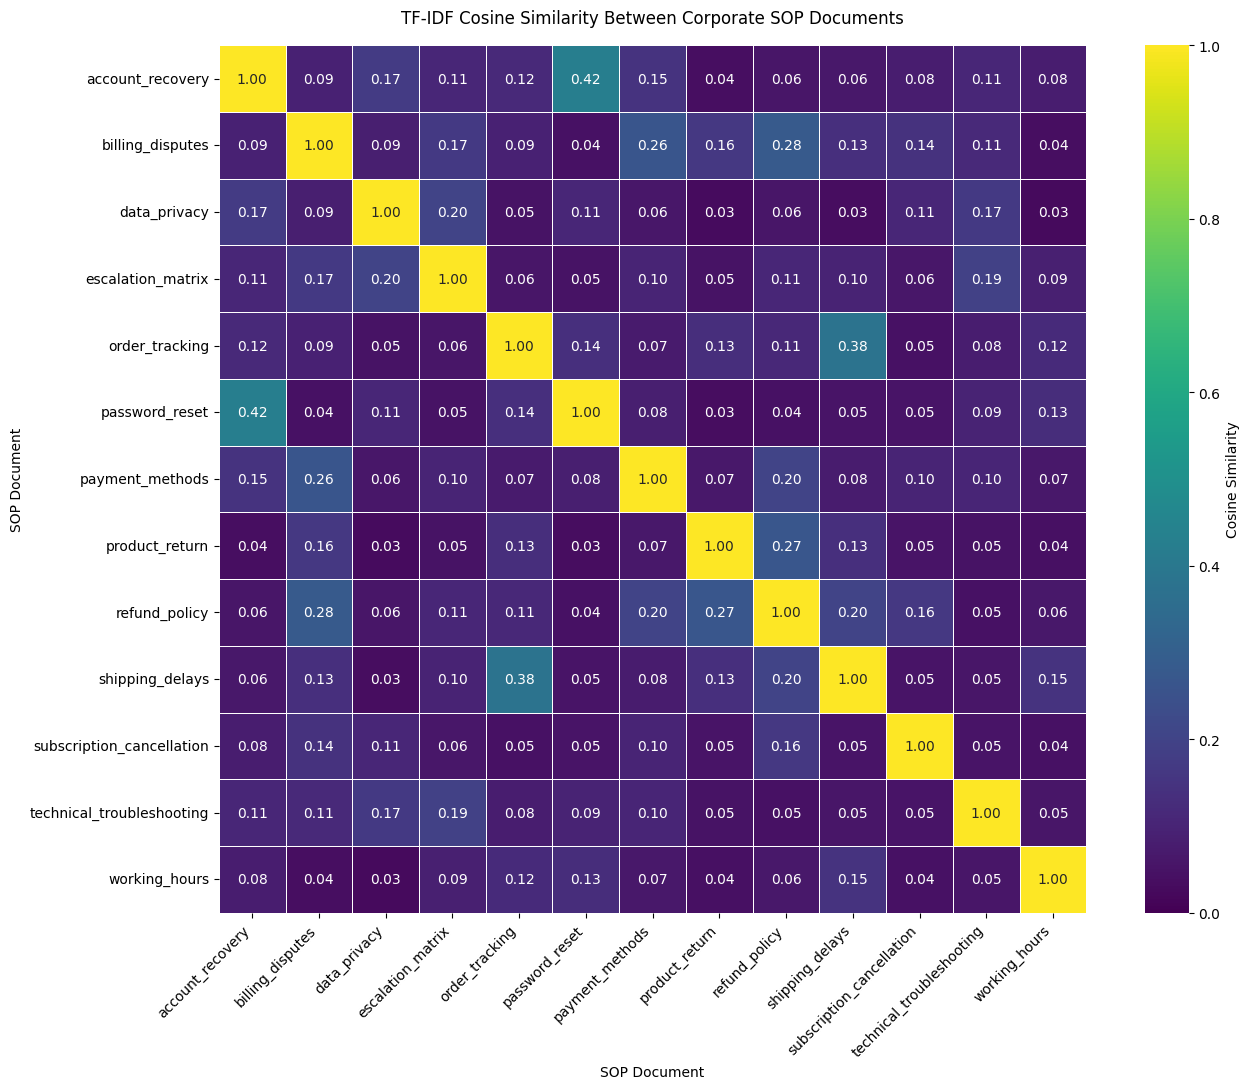

In [22]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confirm that Task 1.3.2 has been completed
if "similarity_df" not in globals():
    raise NameError(
        "similarity_df was not found. Run Task 1.3.2 first."
    )

# Plot the annotated cosine-similarity heatmap
plt.figure(figsize=(14, 11))

sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Cosine Similarity"
    }
)

plt.title(
    "TF-IDF Cosine Similarity Between Corporate SOP Documents",
    pad=16
)
plt.xlabel("SOP Document")
plt.ylabel("SOP Document")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# Interpret off-diagonal similarity values
similarity_values = similarity_df.to_numpy().copy()

# Exclude document-to-itself comparisons
np.fill_diagonal(similarity_values, np.nan)

highest_position = np.unravel_index(
    np.nanargmax(similarity_values),
    similarity_values.shape
)

highest_similarity = similarity_values[highest_position]
highest_policy_1 = similarity_df.index[highest_position[0]]
highest_policy_2 = similarity_df.columns[highest_position[1]]

# Count each policy pair only once using the upper triangle
upper_triangle = similarity_values[
    np.triu_indices_from(similarity_values, k=1)
]

high_overlap_count = np.sum(upper_triangle > 0.50)
low_overlap_count = np.sum(upper_triangle < 0.30)
total_pairs = len(upper_triangle)

print("SOP similarity interpretation")
print("-" * 45)
print(
    f"Most similar policy pair : "
    f"{highest_policy_1} and {highest_policy_2}"
)
print(
    f"Highest off-diagonal similarity: "
    f"{highest_similarity:.3f}"
)
print(
    f"High-overlap pairs (> 0.50) : "
    f"{high_overlap_count} of {total_pairs}"
)
print(
    f"Low-overlap pairs (< 0.30)  : "
    f"{low_overlap_count} of {total_pairs}"
)

if high_overlap_count > 0:
    print(
        "\nSome SOP documents have high textual overlap. "
        "The RAG retriever may require precise query construction "
        "to distinguish these policies."
    )
else:
    print(
        "\nNo SOP pair exceeds the 0.50 high-overlap threshold. "
        "The policies appear sufficiently distinct for retrieval."
    )

SOP similarity interpretation
---------------------------------------------
Most similar policy pair : account_recovery and password_reset
Highest off-diagonal similarity: 0.424
High-overlap pairs (> 0.50) : 0 of 78
Low-overlap pairs (< 0.30)  : 76 of 78

No SOP pair exceeds the 0.50 high-overlap threshold. The policies appear sufficiently distinct for retrieval.


---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [24]:
# YOUR CODE HERE
OUTPUT_PATH = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_1"
    / "sampled_data.csv"
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

final_sample_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved cleaned dataset to:\n{OUTPUT_PATH}")
print(f"Saved records: {len(final_sample_df):,}")

display(final_sample_df.head())

Saved cleaned dataset to:
/content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_1/sampled_data.csv
Saved records: 4,000


,flags,instruction,category,intent,response
0,BLS,shipments to {{Delivery City}},DELIVERY,delivery_options,"Ah, {{Delivery City}}! A city renowned for its..."
1,BLMQZ,I'm trying to notify of errors with registrat...,ACCOUNT,registration_problems,Thank you for bringing this issue to our atten...
2,BCEMQ,i cannot pay help me to report issues with pay...,PAYMENT,payment_issue,I'm sorry to hear that you're having trouble w...
3,BCIL,"I have to see when will my product arrive, how...",DELIVERY,delivery_period,We understand your eagerness to know the estim...
4,BLQZ,need help to check in which cases can Irequest...,REFUND,check_refund_policy,I'm happy to help! I completely understand you...


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [x] Bitext dataset loaded and `.info()` printed
- [x] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [x] Nulls inspected, near-duplicates removed via normalised dedup
- [x] Top 10 intent bar chart rendered
- [x] TF-IDF vectorisation completed on SOP documents
- [x] Cosine similarity heatmap rendered
- [x] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [x] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**